In [21]:
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"]  = 400
plt.style.use('dark_background')

In [25]:
# Testing code generation with a simple task that I could easily do myself.
"""
Prompt:

Please write code in python, using pandas, that does the following:
1. Reads  a csv file 
2. The first column of the csv, called 'gauge_id' identifies one entry (watershed).
Other columns include decimal values showing percentage of spesific land cover class in a spesific year, with a naming convention landuseclass_perc_year.
Each row of this dataframe should be transformed to individual dataframes, where the gauge_id is used for naming the output file later,
present years are set as row index, and columns consist of present land cover classes. The individual watersheds should be gathered to a list. 
3. For every watershed in the list, yearly values should be interpolated for every land cover class.
4. Saving the files to a given directory
"""

# GPT-4o-latest produced functioning code, mistral-codestral-latest produced incorrect code for second step
import os
import pandas as pd
from pathlib import Path

# ====== Configuration ======
input_csv_path = '/media/iielse/T9/CAMELS-FI/data/CAMELS_FI_landcover_attributes.csv'  # <- CHANGE THIS
output_directory = '/media/iielse/T9/CAMELS-FI/data/annual_timeseries'  # <- CHANGE THIS
interpolation_method = 'linear'  # Can be 'linear', 'spline', etc.

# Ensure output directory exists
Path(output_directory).mkdir(parents=True, exist_ok=True)

# ====== Step 1: Read CSV ======
df = pd.read_csv(input_csv_path)

# Drop rows where gauge_id is missing
df = df.dropna(subset=['gauge_id'])

# Identify land cover columns (assumes format: class_perc_year)
land_cover_columns = [col for col in df.columns if col != 'gauge_id']

# Parse unique land cover classes and all years
parsed = []
for col in land_cover_columns:
    try:
        class_part, _, year_part = col.rpartition('_perc_')
        year = int(year_part)
        parsed.append((col, class_part, year))
    except Exception as e:
        print(f"Skipping column {col}: {e}")

# Create a mapping: gauge_id -> individual watershed DataFrame
watershed_dataframes = []

for _, row in df.iterrows():
    gauge_id = row['gauge_id']
    watershed_records = []

    for original_col, land_class, year in parsed:
        value = row.get(original_col, None)
        if pd.notna(value):
            watershed_records.append((year, land_class, value))

    if not watershed_records:
        continue  # skip empty watersheds

    temp_df = pd.DataFrame(watershed_records, columns=['year', 'land_class', 'percentage'])
    pivot_df = temp_df.pivot(index='year', columns='land_class', values='percentage')
    pivot_df = pivot_df.sort_index()

    # Step 3: Interpolate missing years
    pivot_df = pivot_df.interpolate(method=interpolation_method).reindex(
        range(pivot_df.index.min(), pivot_df.index.max() + 1)
    ).interpolate(method=interpolation_method)
    # Added by me
    pivot_df = pivot_df.round(2)
    watershed_dataframes.append((gauge_id, pivot_df))

    # Step 4: Save to CSV
    output_path = os.path.join(output_directory, f'CAMELS_FI_landcover_timeseries_{gauge_id}_2000-2018.csv')
    pivot_df.to_csv(output_path)

In [18]:
# Checking the range of values for writing
range_df = pd.DataFrame(columns=watershed_dataframes[0][1].columns)
for gauge_id, watershed in watershed_dataframes:
    range_df.loc[gauge_id] = list(watershed.max() - watershed.min())

<Axes: >

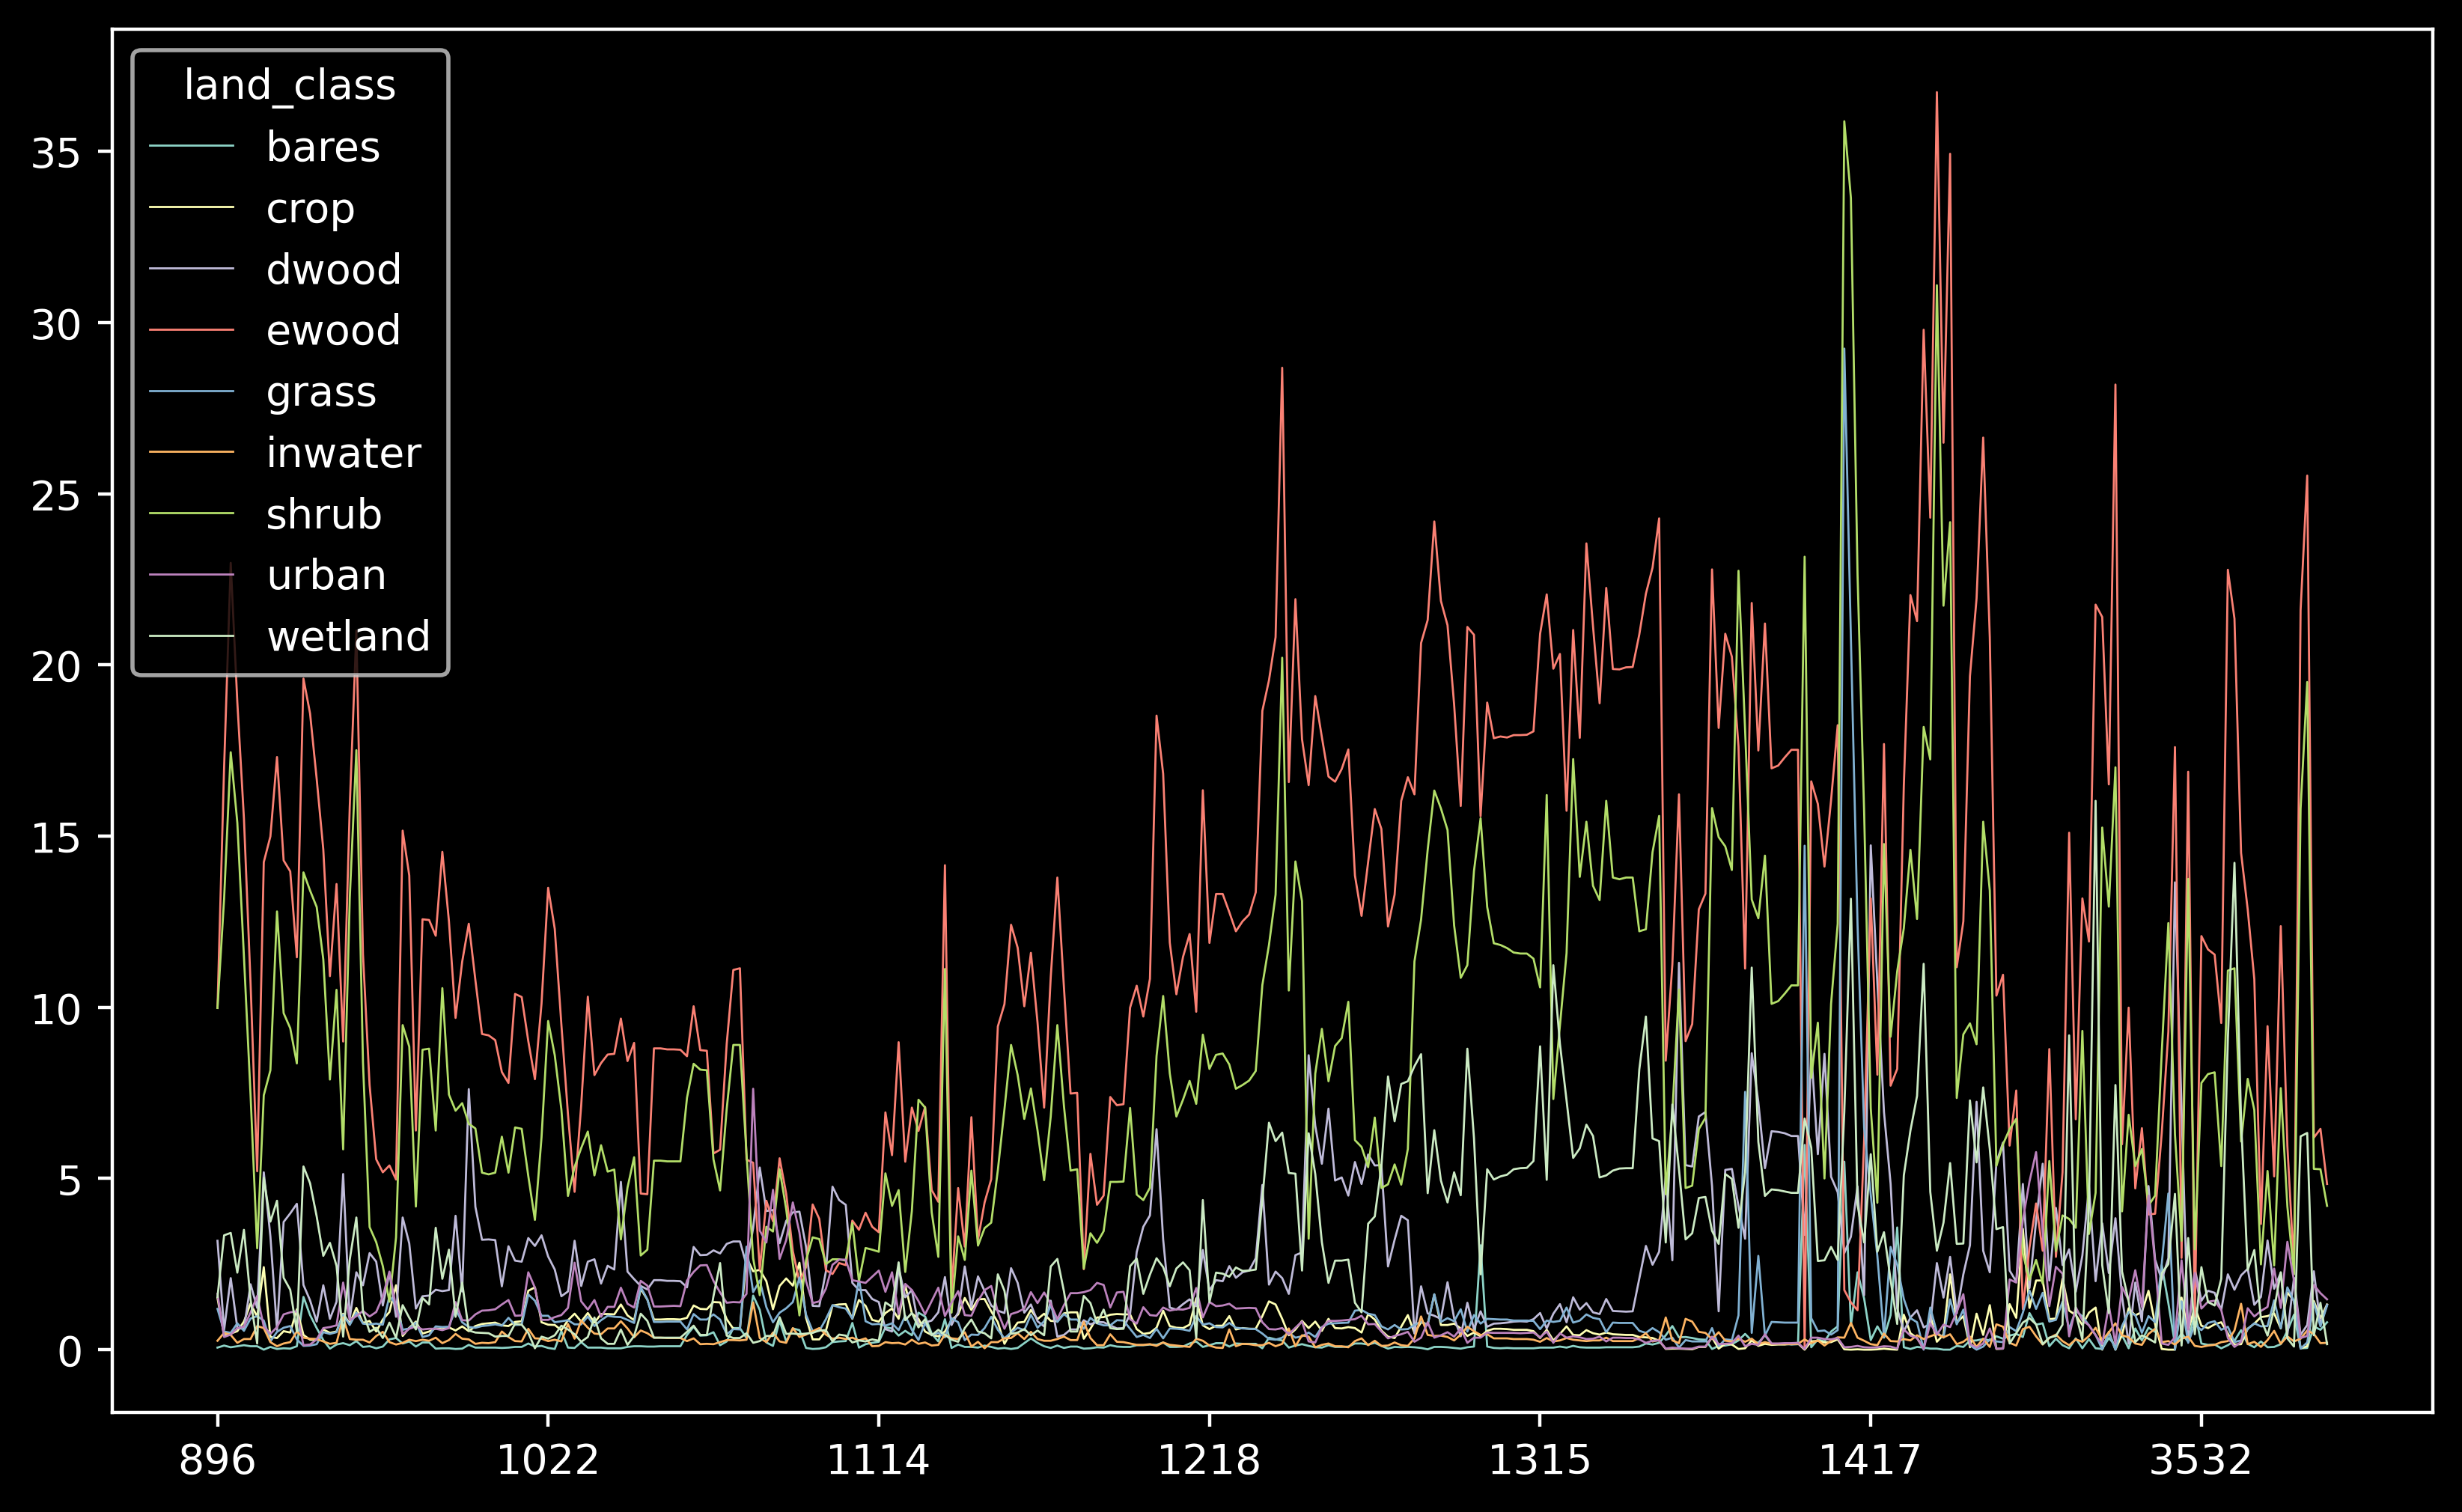

In [24]:
range_df.plot(linewidth=0.5, figsize=(10, 6))

In [ ]:
# codestral-latest, transform_dataframe() crashes
import pandas as pd
import os

def read_csv(file_path):
    """Reads a CSV file into a pandas DataFrame."""
    return pd.read_csv(file_path)

def transform_dataframe(df):
    """Transforms the DataFrame into individual DataFrames for each watershed."""
    watersheds = []
    for index, row in df.iterrows():
        gauge_id = row['gauge_id']
        watershed_df = row.drop('gauge_id').to_frame().T
        watershed_df.columns = [col.split('_')[0] for col in watershed_df.columns]
        watershed_df.index = [int(col.split('_')[2]) for col in df.columns if col != 'gauge_id']
        watersheds.append((gauge_id, watershed_df))
    return watersheds

def interpolate_watersheds(watersheds):
    """Interpolates yearly values for each land cover class in each watershed."""
    interpolated_watersheds = []
    for gauge_id, watershed_df in watersheds:
        interpolated_df = watershed_df.T.interpolate(method='linear').T
        interpolated_watersheds.append((gauge_id, interpolated_df))
    return interpolated_watersheds

def save_watersheds_to_csv(watersheds, directory):
    """Saves each watershed DataFrame to a CSV file in the specified directory."""
    if not os.path.exists(directory):
        os.makedirs(directory)
    for gauge_id, watershed_df in watersheds:
        file_path = os.path.join(directory, f"{gauge_id}.csv")
        watershed_df.to_csv(file_path)

def main(file_path, output_directory):
    """Main function to read, transform, interpolate, and save watershed data."""
    df = read_csv(file_path)
    watersheds = transform_dataframe(df)
    interpolated_watersheds = interpolate_watersheds(watersheds)
    save_watersheds_to_csv(interpolated_watersheds, output_directory)

# Example usage
file_path = 'path/to/your/input.csv'
output_directory = 'path/to/your/output/directory'
main(file_path, output_directory)